In [1]:
import pandas as pd
from stock_data_analyser import *

In [2]:
sda= StockDataAnalyser(stock_symbol='MSFT')
sda.fetch_from_db_and_analyze()

In [3]:
df=sda.stock_data


In [4]:
# df['Close_Lead1'] = df['Close'].shift(-10)
for i in range(1,5):
    df[f"Close_Lead{i}"] = df['Close'].shift(-i)
df.dropna(inplace=True)


In [5]:
df.columns

Index(['index', 'Open', 'High', 'Low', 'Close', 'Volume', 'EMA',
       'Bollinger_Upper', 'Bollinger_Lower', 'Close_Lag1', 'Close_Lag2',
       'Close_Lag3', 'Close_Lag4', 'Close_Lag5', 'Close_Lag6', 'Close_Lag7',
       'Close_Lag8', 'Close_Lag9', 'Close_Lag10', 'Close_Lag11', 'Close_Lag12',
       'Close_Lag13', 'Close_Lag14', 'Close_Lag15', 'Close_Lag16',
       'Close_Lag17', 'Close_Lag18', 'Close_Lag19', 'Trend', 'Stock_name',
       'Close_Lead1', 'Close_Lead2', 'Close_Lead3', 'Close_Lead4'],
      dtype='object')

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [9]:
# Drop non-numeric and target column from features


# Define input (X) and target (y)
X = df.drop(columns=['Open', 'High', 'Low', 'Volume', 'EMA', 'Bollinger_Upper', 'Bollinger_Lower', 'Trend', 'Stock_name', 'index', 'Close_Lead1', 'Close_Lead2', 'Close_Lead3', 'Close_Lead4']).values  # Features
y = df[['Close_Lead1', 'Close_Lead2', 'Close_Lead3', 'Close_Lead4']].values  # Target variable


In [18]:
y.shape
X.shape

(956, 20)

In [23]:

# Normalize features
scalerX = StandardScaler()
scalerY = StandardScaler()
# X = scalerX.fit_transform(X)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
X_train = scalerX.fit_transform(X_train)
X_test = scalerX.transform(X_test)
y_train = scalerY.fit_transform(y_train)
y_test = scalerY.transform(y_test)


In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((764, 20), (192, 20), (764, 4), (192, 4))

In [34]:
# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),  
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(4)  # Output layer for regression (no activation)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.2f}")

Epoch 1/50


/home/steeldev/Desktop/Github/PotatoTrade/mlenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 539084480.0000 - mae: 22756.2598 - val_loss: 525190880.0000 - val_mae: 22481.6562
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 540717312.0000 - mae: 22763.1387 - val_loss: 510851488.0000 - val_mae: 22164.3184
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 507760768.0000 - mae: 22039.3965 - val_loss: 383781120.0000 - val_mae: 19037.0645
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 306569696.0000 - mae: 16474.3711 - val_loss: 131151136.0000 - val_mae: 9343.3721
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 129625664.0000 - mae: 9303.0928 - val_loss: 118374904.0000 - val_mae: 8343.0586
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 111552976.0000 - mae: 8322.7178 - val_loss: 112807040.0000 - val_mae: 8199.4072
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 105171488.0000 - mae: 8001.1978 - val_loss: 110917096.0000 - val_mae: 8143.6138
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 

In [44]:
X.shape

(980, 18)

In [35]:
import matplotlib.pyplot as plt

# Get predictions
y_train_pred = scalerY.inverse_transform(model.predict(X_train))
y_test_pred = scalerY.inverse_transform(model.predict(X_test))
y_train = scalerY.inverse_transform(y_train)
y_test = scalerY.inverse_transform(y_test)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [28]:
X_train.shape

(764, 20)

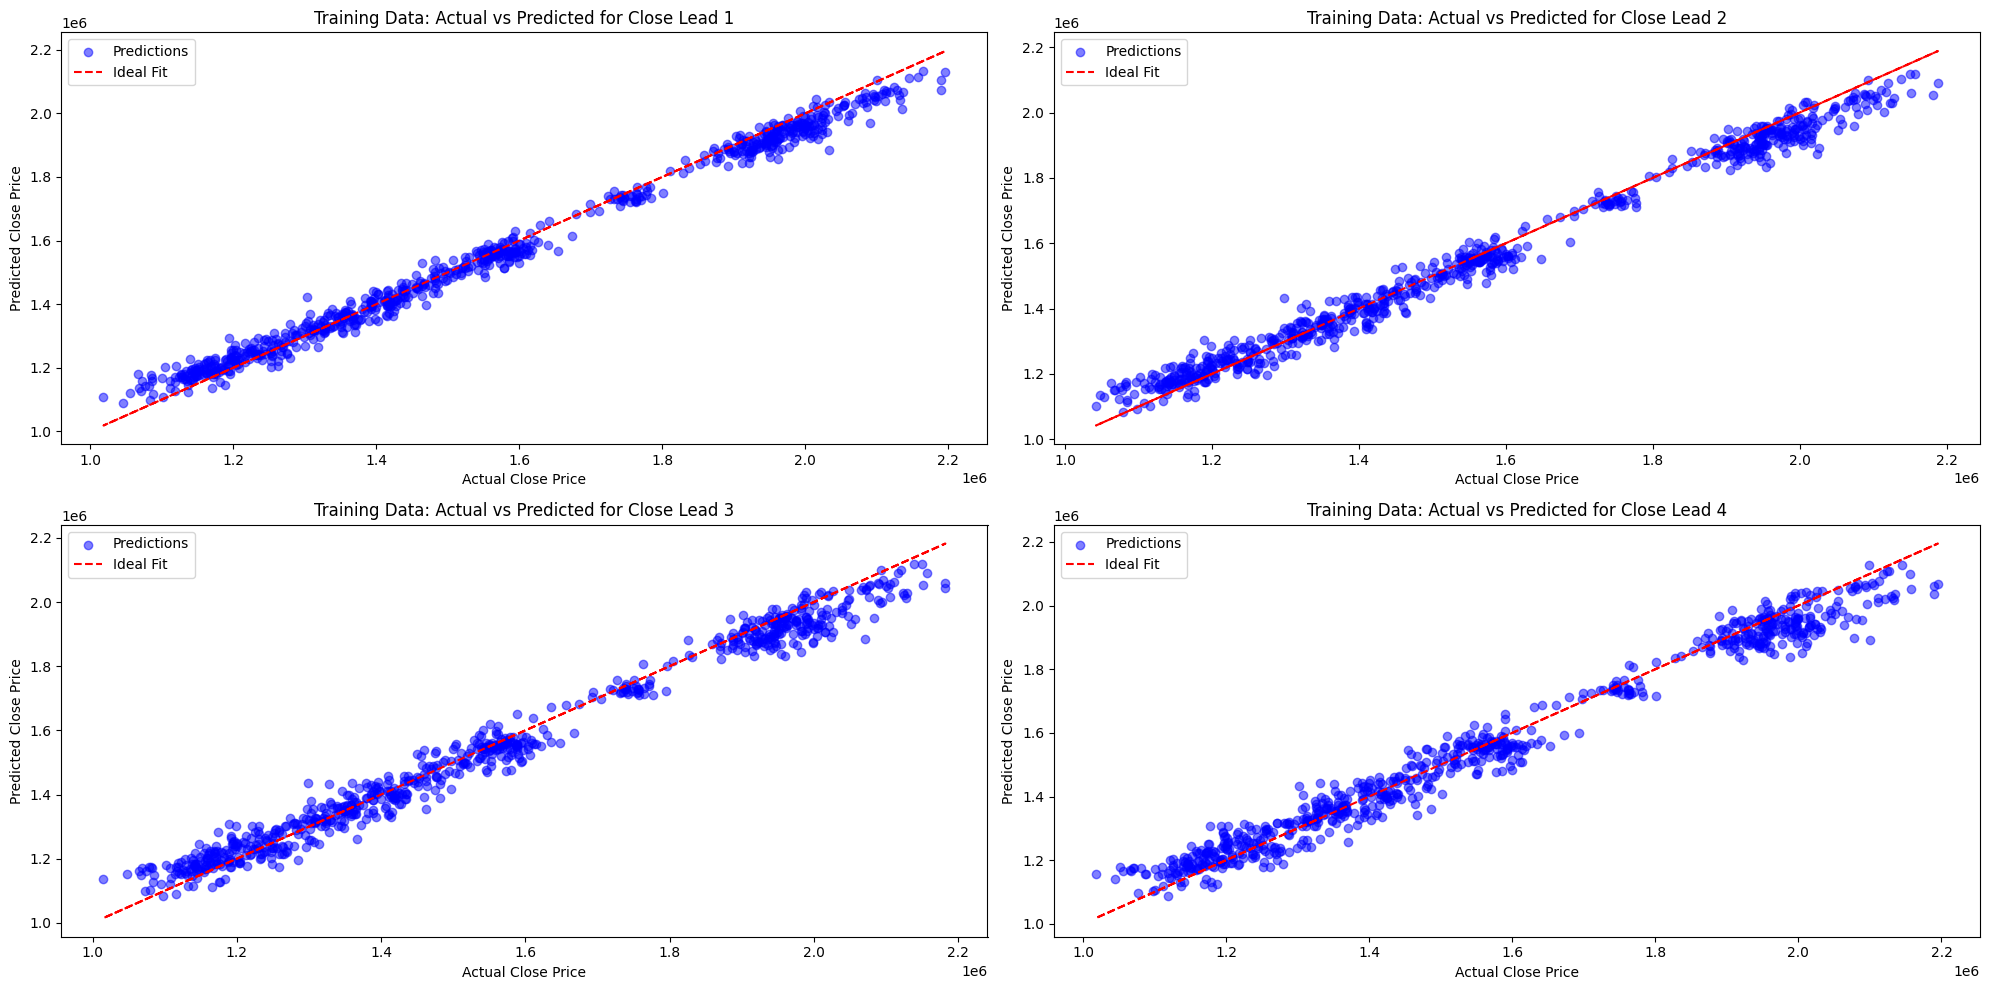

In [36]:
plt.figure(figsize=(20,10))
for i in range(1,5):
    plt.subplot(2,2,i)
    plt.scatter(y_train[:,i-1], y_train_pred[:,i-1], alpha=0.5, color='blue', label="Predictions")
    plt.plot(y_train[:,i-1], y_train[:,i-1], color='red', linestyle='dashed', label="Ideal Fit")
    plt.xlabel("Actual Close Price")
    plt.ylabel("Predicted Close Price")
    plt.title(f"Training Data: Actual vs Predicted for Close Lead {i}")
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Plot Training Data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label="Predictions")
plt.plot(y_train, y_train, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Training Data: Actual vs Predicted")
plt.legend()

# Plot Testing Data
# plt.subplot(1, 2, 2)
# plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', label="Predictions")
# plt.plot(y_test, y_test, color='red', linestyle='dashed', label="Ideal Fit")
# plt.xlabel("Actual Close Price")
# plt.ylabel("Predicted Close Price")
# plt.title("Testing Data: Actual vs Predicted")
# plt.legend()

plt.tight_layout()
plt.show()


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


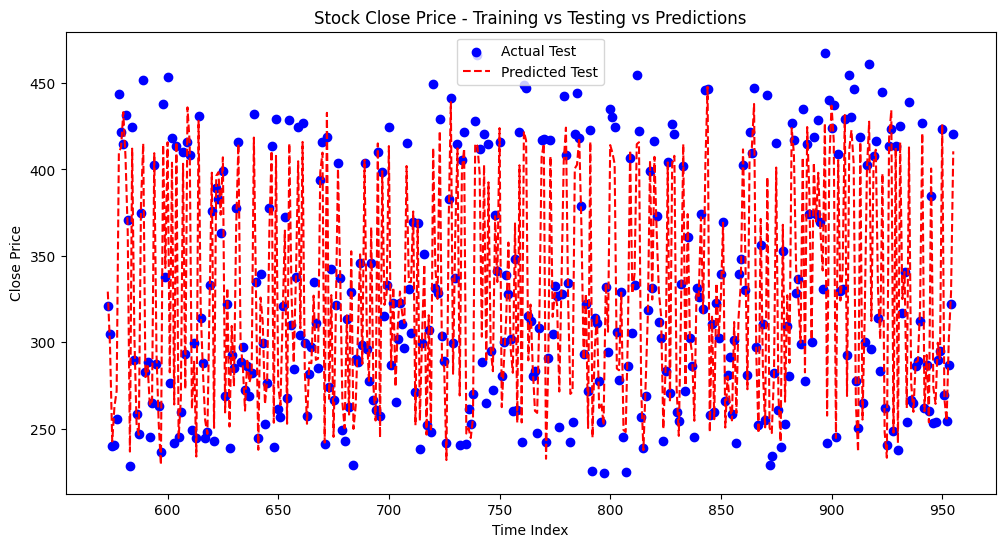

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_train_pred = scalerY.inverse_transform(model.predict(X_train))
y_test_pred = scalerY.inverse_transform(model.predict(X_test))

# Create indices for plotting
train_indices = np.arange(len(y_train))
test_indices = np.arange(len(y_train), len(y_train) + len(y_test))

# Plot actual and predicted closing prices
plt.figure(figsize=(12, 6))

# plt.plot(train_indices, y_train, label="Actual Train", color='blue', linewidth=1)
# plt.plot(train_indices, y_train_pred, label="Predicted Train", color='cyan', linestyle='dashed')

plt.scatter(test_indices, y_test, label="Actual Test", color='blue', linewidth=1)
plt.plot(test_indices, y_test_pred, label="Predicted Test", color='red', linestyle='dashed')

plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.title("Stock Close Price - Training vs Testing vs Predictions")
plt.legend()
plt.show()


Test MAE: 9.97


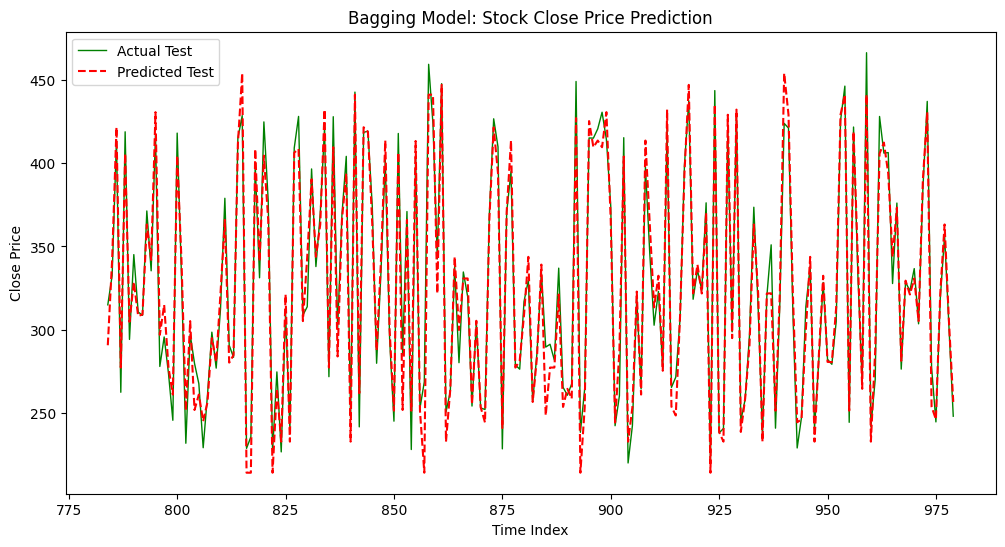

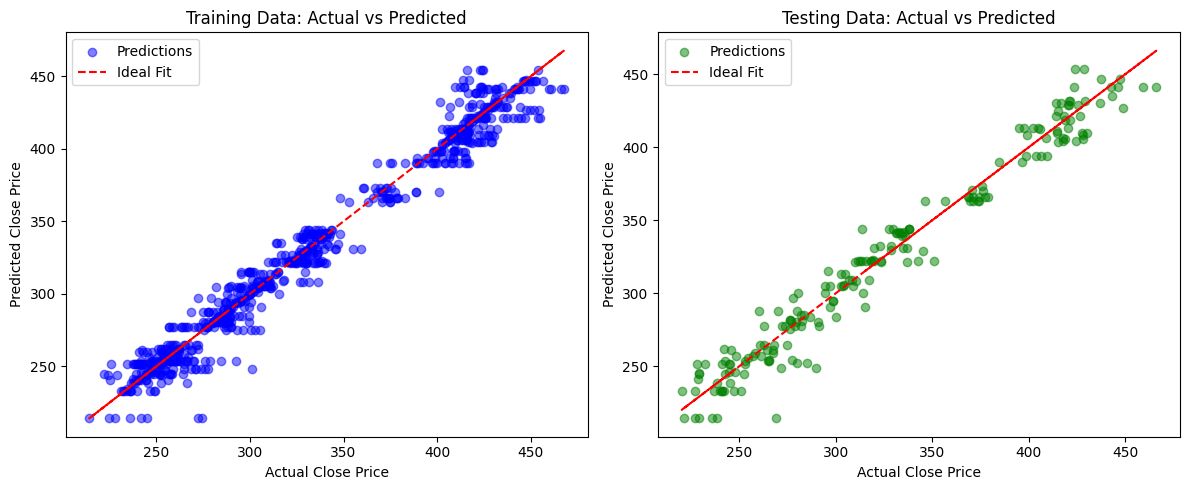

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
# Define Bagging Regressor with Decision Trees
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),  # Use 'estimator' instead of 'base_estimator'
    n_estimators=1,  
    max_samples=0.2,  
    bootstrap=True,   
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
bagging_model.fit(X_train, y_train)

# Get predictions
y_train_pred = bagging_model.predict(X_train)
y_test_pred = bagging_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test MAE: {mae:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
# plt.plot(range(len(y_train)), y_train, label="Actual Train", color='blue', linewidth=1)
# plt.plot(range(len(y_train)), y_train_pred, label="Predicted Train", color='cyan', linestyle='dashed')

plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test, label="Actual Test", color='green', linewidth=1)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test_pred, label="Predicted Test", color='red', linestyle='dashed')

plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.title("Bagging Model: Stock Close Price Prediction")
plt.legend()
plt.show()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label="Predictions")
plt.plot(y_train, y_train, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Training Data: Actual vs Predicted")
plt.legend()

# Plot Testing Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', label="Predictions")
plt.plot(y_test, y_test, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Testing Data: Actual vs Predicted")
plt.legend()

plt.tight_layout()
plt.show()